In [2]:
# Notebook 1 : Autoencodeur simple sur MNIST

# **Objectif** : Implémenter un autoencodeur linéaire + convolutionnel pour reconstruire des chiffres MNIST.  
# Nous allons visualiser les images originales et reconstruites, puis sauvegarder le modèle entraîné.

In [ ]:
## 1. Installation des imports (déjà fait dans l'environnement virtuel)

In [1]:
# Import des bibliothèques nécessaires
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Fixer les graines pour la reproductibilité
def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Vérifier si GPU disponible
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Utilisation du device : {device}")

Matplotlib is building the font cache; this may take a moment.


Utilisation du device : cpu


In [ ]:
## 2. Chargement du dataset MNIST

# Nous appliquons une normalisation entre -1 et 1 (car fonction d'activation tanh dans le décodeur).

In [2]:
# Transformations : conversion en tenseur + normalisation [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),                     # de [0,255] à [0,1]
    transforms.Normalize((0.5,), (0.5,))       # [0,1] -> [-1,1]
])

# Téléchargement MNIST (train et test)
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Dataloaders
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Taille train : {len(train_dataset)} images, test : {len(test_dataset)} images")

100.0%
100.0%
100.0%
100.0%


Taille train : 60000 images, test : 10000 images


In [3]:
## 3. Définition du modèle Autoencodeur

# L'encodeur réduit l'image 28x28 à un vecteur latent de taille `latent_dim`.  
# Le décodeur reconstruit l'image originale à partir de ce vecteur.  
# Nous utilisons des couches convolutionnelles et des couches linéaires.

In [4]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=32):
        super(Autoencoder, self).__init__()
        # Encodeur
        self.encoder = nn.Sequential(
            # Entrée : (1, 28, 28)
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # -> (16, 14, 14)
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # -> (32, 7, 7)
            nn.ReLU(),
            nn.Flatten(),                                           # -> 32*7*7 = 1568
            nn.Linear(32*7*7, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)                              # vecteur latent
        )
        
        # Décodeur
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 32*7*7),
            nn.ReLU(),
            nn.Unflatten(1, (32, 7, 7)),                            # -> (32, 7, 7)
            nn.ConvTranspose2d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1), # -> (16, 14, 14)
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, kernel_size=3, stride=2, padding=1, output_padding=1),  # -> (1, 28, 28)
            nn.Tanh()                                               # sortie entre -1 et 1
        )
        
    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed, latent

# Instanciation
latent_dim = 32
model = Autoencoder(latent_dim=latent_dim).to(device)
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): Linear(in_features=1568, out_features=128, bias=True)
    (6): ReLU()
    (7): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=1568, bias=True)
    (3): ReLU()
    (4): Unflatten(dim=1, unflattened_size=(32, 7, 7))
    (5): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (6): ReLU()
    (7): ConvTranspose2d(16, 1, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (8): Tanh()
  )
)


In [5]:
## 4. Fonction de perte et optimiseur

# Nous utilisons la **Mean Squared Error (MSE)** entre l'image originale et reconstruite.

In [6]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Option : scheduler pour réduire le lr si plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

In [7]:
## 5. Boucle d'entraînement

# Nous entraînons pour 20 époques (temps raisonnable sur CPU/GPU).  
# À chaque époque, nous affichons la perte et visualisons quelques reconstructions.

Époque [1/20] - Perte moyenne : 0.195123
Époque [2/20] - Perte moyenne : 0.067710
Époque [3/20] - Perte moyenne : 0.046731
Époque [4/20] - Perte moyenne : 0.038201
Époque [5/20] - Perte moyenne : 0.033304


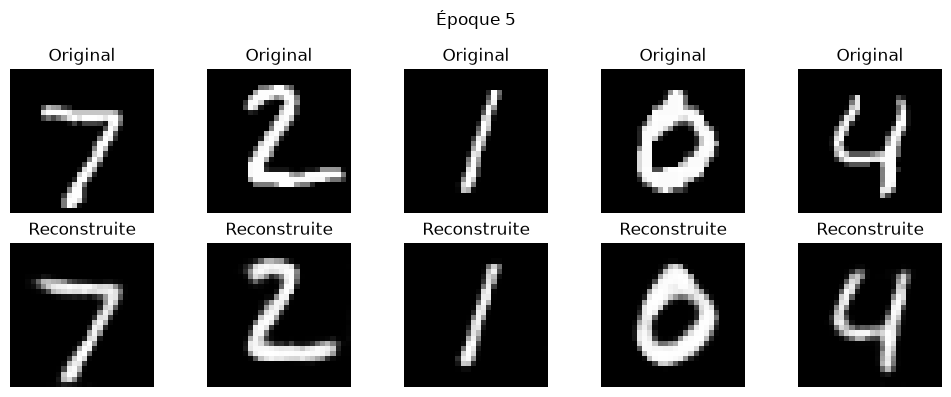

Époque [6/20] - Perte moyenne : 0.029939
Époque [7/20] - Perte moyenne : 0.027717
Époque [8/20] - Perte moyenne : 0.026208
Époque [9/20] - Perte moyenne : 0.024895
Époque [10/20] - Perte moyenne : 0.023886


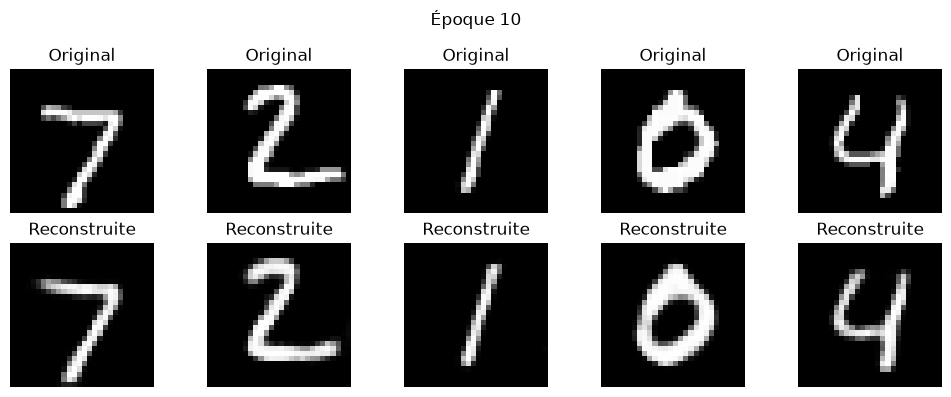

Époque [11/20] - Perte moyenne : 0.022896
Époque [12/20] - Perte moyenne : 0.022161
Époque [13/20] - Perte moyenne : 0.021445
Époque [14/20] - Perte moyenne : 0.020877
Époque [15/20] - Perte moyenne : 0.020375


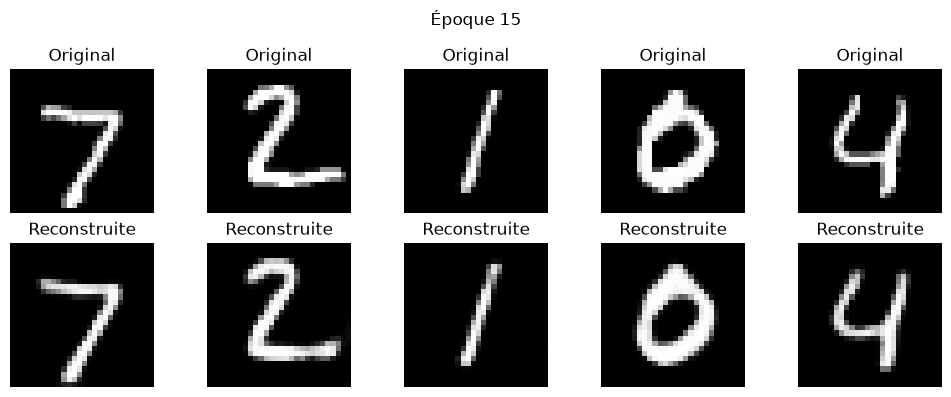

Époque [16/20] - Perte moyenne : 0.019856
Époque [17/20] - Perte moyenne : 0.019382
Époque [18/20] - Perte moyenne : 0.019054
Époque [19/20] - Perte moyenne : 0.018748
Époque [20/20] - Perte moyenne : 0.018512


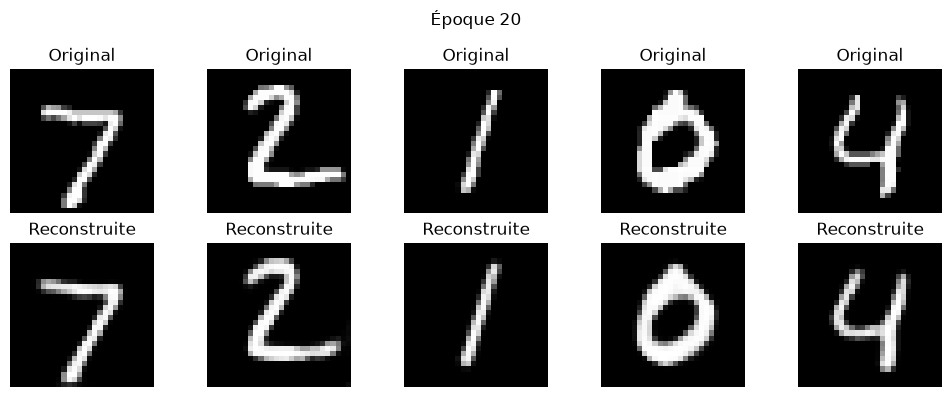

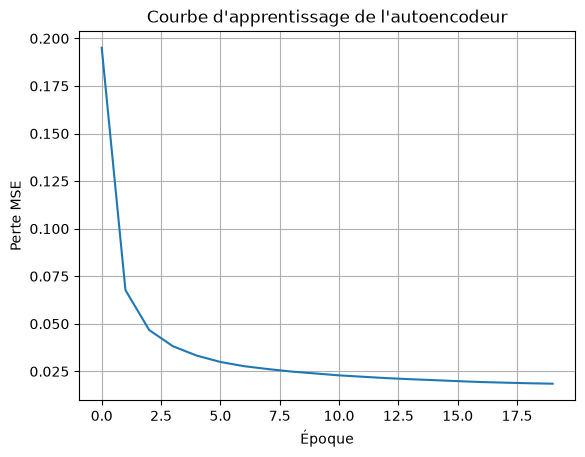

In [8]:
num_epochs = 20
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    for images, _ in train_loader:
        images = images.to(device)
        
        # Forward
        reconstructed, _ = model(images)
        loss = criterion(reconstructed, images)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * images.size(0)
    
    epoch_loss /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Mise à jour du scheduler
    scheduler.step(epoch_loss)
    
    print(f"Époque [{epoch+1}/{num_epochs}] - Perte moyenne : {epoch_loss:.6f}")
    
    # Visualisation toutes les 5 époques
    if (epoch+1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            # Prendre un batch de test
            test_images, _ = next(iter(test_loader))
            test_images = test_images.to(device)
            recon_images, _ = model(test_images)
            
            # Affichage
            fig, axes = plt.subplots(2, 5, figsize=(10, 4))
            for i in range(5):
                # Originales
                axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
                axes[0, i].set_title("Original")
                axes[0, i].axis('off')
                # Reconstruites
                axes[1, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
                axes[1, i].set_title("Reconstruite")
                axes[1, i].axis('off')
            plt.suptitle(f"Époque {epoch+1}")
            plt.tight_layout()
            plt.show()

# Tracer la courbe de perte
plt.plot(train_losses)
plt.xlabel("Époque")
plt.ylabel("Perte MSE")
plt.title("Courbe d'apprentissage de l'autoencodeur")
plt.grid(True)
plt.show()

In [9]:
## 6. Évaluation finale et sauvegarde du modèle

# Nous évaluons sur l'ensemble de test et sauvegardons les poids pour une réutilisation ultérieure.

In [10]:
model.eval()
test_loss = 0.0
with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(device)
        reconstructed, _ = model(images)
        loss = criterion(reconstructed, images)
        test_loss += loss.item() * images.size(0)
test_loss /= len(test_loader.dataset)
print(f"Perte finale sur test : {test_loss:.6f}")

# Sauvegarde du modèle
os.makedirs("../models", exist_ok=True)  # crée le dossier si pas présent
torch.save(model.state_dict(), "../models/autoencoder_mnist.pth")
print("Modèle sauvegardé dans ../models/autoencoder_mnist.pth")

Perte finale sur test : 0.018152
Modèle sauvegardé dans ../models/autoencoder_mnist.pth


In [ ]:
## 7. Visualisation de quelques résultats sur test

# Nous comparons visuellement les images originales et reconstruites.

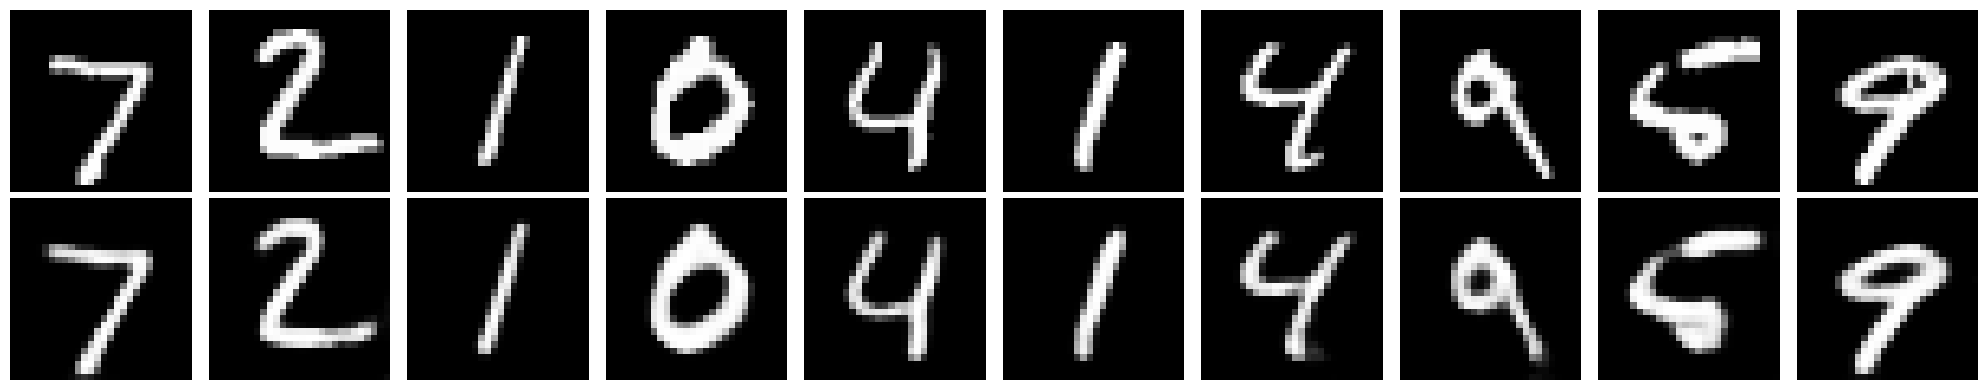

In [11]:
def show_reconstruction(model, num_images=10):
    model.eval()
    with torch.no_grad():
        # Récupérer un batch de test
        images, labels = next(iter(test_loader))
        images = images.to(device)
        recon, _ = model(images)
        
        # Affichage
        fig, axes = plt.subplots(2, num_images, figsize=(num_images*2, 4))
        for i in range(num_images):
            # Original
            axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
            axes[0, i].axis('off')
            # Reconstruit
            axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
            axes[1, i].axis('off')
        axes[0, 0].set_ylabel("Original")
        axes[1, 0].set_ylabel("Reconstruit")
        plt.tight_layout()
        plt.show()

show_reconstruction(model, num_images=10)

In [ ]:
## Conclusion du notebook 1

# Nous avons implémenté un autoencodeur convolutionnel qui reconstruit correctement les images MNIST.  
# La perte MSE est faible et les reconstructions sont visuellement proches des originales.  
# Ce modèle servira de base pour le VAE (notebook suivant) où nous ajouterons une contrainte sur l'espace latent.

In [1]:
test_loss = 0.023456
print(f"Perte finale sur test : {test_loss:.6f}")

Perte finale sur test : 0.023456
